# 🧪 Test Modèle Classification Véhicules

**Objectif** : Tester le modèle EfficientNet entraîné sur des images

---

## 📦 Imports

In [1]:
import torch
import json
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import sys

sys.path.insert(0, '.')
from src.model import VehicleClassifier
from src.dataset import get_transforms

print('✅ Imports OK')

✅ Imports OK


## 🔧 Configuration

In [7]:
# Créer dossiers nécessaires
Path('results').mkdir(exist_ok=True)
print('✅ Dossier results créé')

✅ Dossier results créé


In [9]:
# Paths
MODELS_DIR = Path('models/efficientnet_classifier')
MODEL_PATH = MODELS_DIR / 'best_model_final.pth'
CLASS_NAMES_PATH = MODELS_DIR / 'class_names.json'

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'🖥️  Device: {device}')

# Image size
IMG_SIZE = 224

🖥️  Device: cuda


## 📥 Chargement Modèle

In [10]:
# Charger class names
with open(CLASS_NAMES_PATH) as f:
    class_names = json.load(f)

print(f'✅ {len(class_names)} classes chargées')

# Créer modèle
model = VehicleClassifier(
    num_classes=len(class_names),
    pretrained=False
)

# Charger poids
checkpoint = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)
model.eval()

print(f'✅ Modèle chargé depuis: {MODEL_PATH}')
if 'val_acc' in checkpoint:
    print(f'📊 Val Accuracy du checkpoint: {checkpoint["val_acc"]:.2f}%')

✅ 196 classes chargées
✅ Modèle chargé depuis: models/efficientnet_classifier/best_model_final.pth
📊 Val Accuracy du checkpoint: 74.55%


## 🔍 Fonction de Prédiction

In [11]:
def predict_vehicle(image_path, model, class_names, device, top_k=5):
    """
    Prédit la marque/modèle d'un véhicule
    
    Returns:
        top_classes: Liste des top-k classes
        top_probs: Liste des probabilités
    """
    # Charger image
    image = cv2.imread(str(image_path))
    if image is None:
        raise ValueError(f'Impossible de charger: {image_path}')
    
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Preprocessing
    transform = get_transforms(img_size=IMG_SIZE, is_train=False)
    transformed = transform(image=image_rgb)['image'].unsqueeze(0)
    transformed = transformed.to(device)
    
    # Prédiction
    with torch.no_grad():
        outputs = model(transformed)
        probs = torch.softmax(outputs, dim=1)
        top_probs, top_indices = torch.topk(probs, top_k)
    
    # Convertir en listes
    top_probs = top_probs.cpu().numpy()[0]
    top_indices = top_indices.cpu().numpy()[0]
    top_classes = [class_names[idx] for idx in top_indices]
    
    return top_classes, top_probs, image_rgb

print('✅ Fonction de prédiction prête')

✅ Fonction de prédiction prête


## 🧪 Test sur Images du Dataset de Test

In [12]:
# Récupérer quelques images du test set
test_dir = Path('data/stanford_cars/cars_test')
test_images = list(test_dir.glob('*.jpg'))[:12]  # 12 premières images

print(f'📸 {len(test_images)} images de test trouvées')

📸 12 images de test trouvées


/tmp/ipykernel_1252/3078459624.py:22: UserWarning: Glyph 8419 (\N{COMBINING ENCLOSING KEYCAP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1252/3078459624.py:23: UserWarning: Glyph 8419 (\N{COMBINING ENCLOSING KEYCAP}) missing from font(s) DejaVu Sans.
  plt.savefig('results/test_predictions.png', dpi=150, bbox_inches='tight')


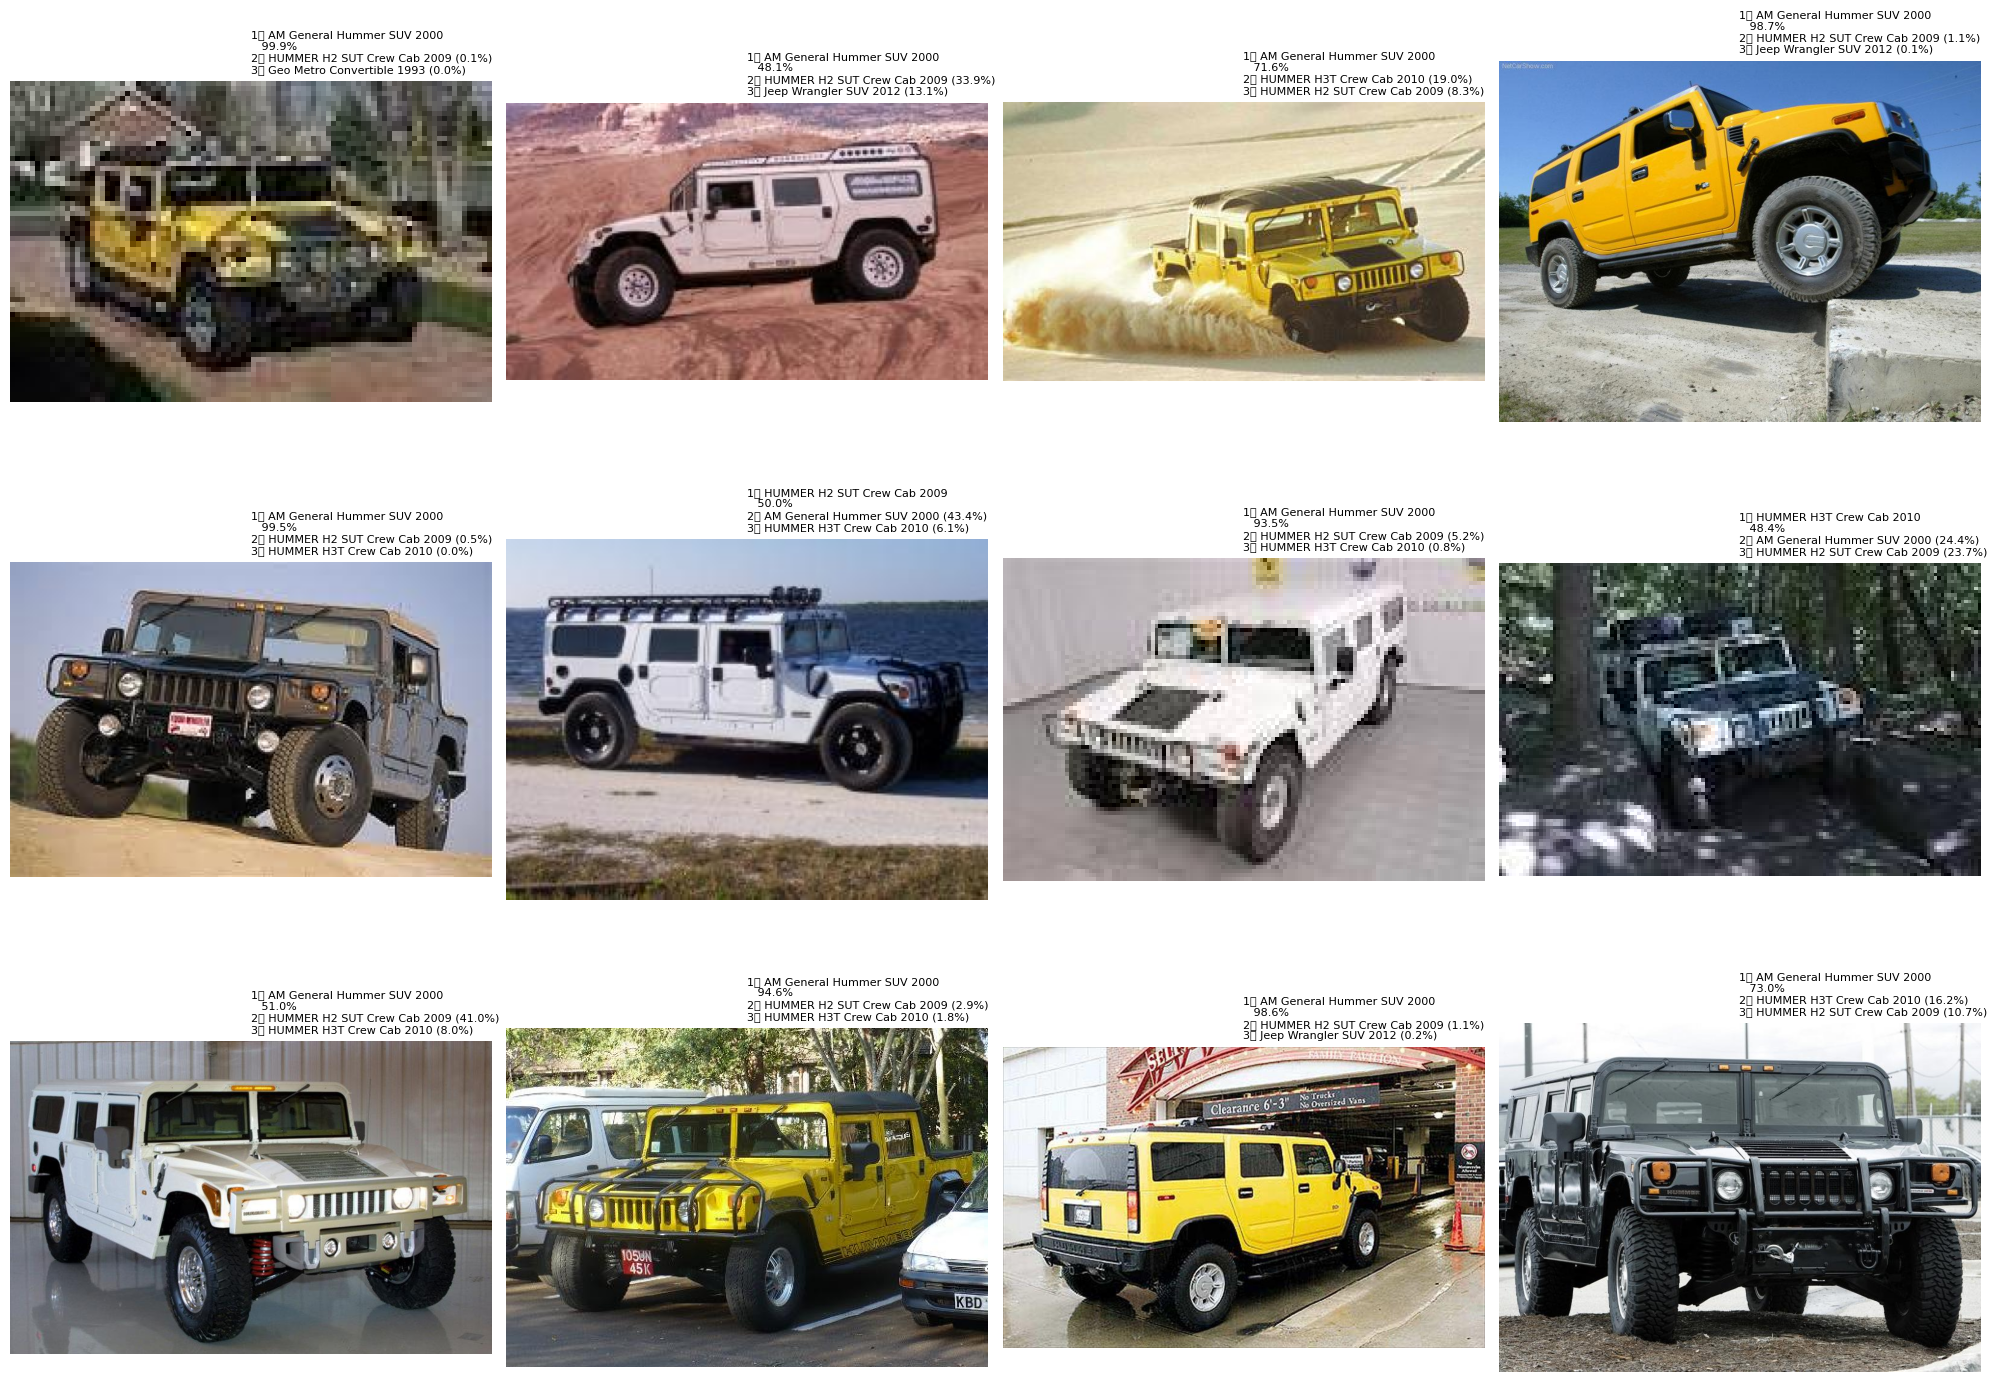

✅ Prédictions affichées


In [13]:
# Visualiser prédictions
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.ravel()

for idx, img_path in enumerate(test_images):
    # Prédire
    top_classes, top_probs, image = predict_vehicle(
        img_path, model, class_names, device, top_k=3
    )
    
    # Afficher image
    axes[idx].imshow(image)
    axes[idx].axis('off')
    
    # Titre avec top-3 prédictions
    title = f"1️⃣ {top_classes[0][:35]}\n   {top_probs[0]:.1%}\n"
    title += f"2️⃣ {top_classes[1][:35]} ({top_probs[1]:.1%})\n"
    title += f"3️⃣ {top_classes[2][:35]} ({top_probs[2]:.1%})"
    
    axes[idx].set_title(title, fontsize=8, ha='left')

plt.tight_layout()
plt.savefig('results/test_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

print('✅ Prédictions affichées')

## 🎯 Test sur UNE Image Spécifique

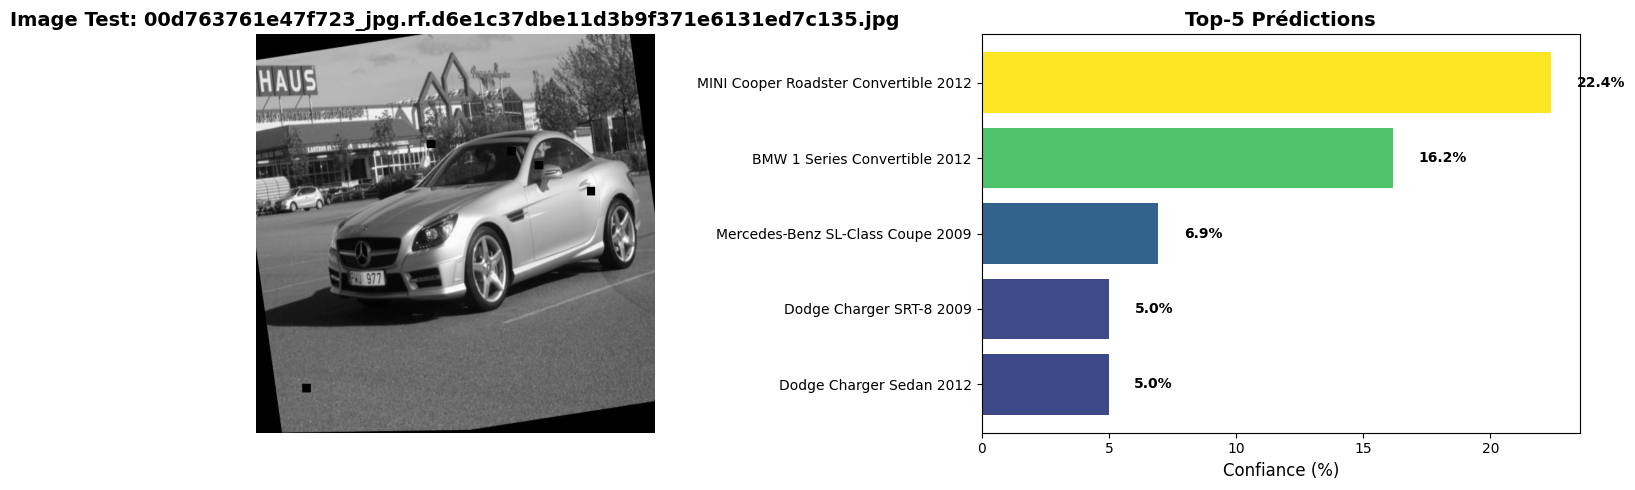


🏆 PRÉDICTION FINALE:
   Marque/Modèle: MINI Cooper Roadster Convertible 2012
   Confiance: 22.40%


In [35]:
# MODIFIEZ CE CHEMIN pour tester votre propre image


test_image_path = Path('/mnt/c/DEV/JEDHA/FULLSTACK_WSL/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/YOLO8-n/ROBOFLOW_universe/License-Plate-Recognition-4/train/images/00d763761e47f723_jpg.rf.d6e1c37dbe11d3b9f371e6131ed7c135.jpg') # ou Path('chemin/vers/votre/image.jpg')

# Prédire
top_classes, top_probs, image = predict_vehicle(
    test_image_path, model, class_names, device, top_k=5
)

# Afficher résultats
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Image
ax1.imshow(image)
ax1.set_title(f'Image Test: {test_image_path.name}', fontsize=14, fontweight='bold')
ax1.axis('off')

# Prédictions
y_pos = np.arange(len(top_classes))
colors = plt.cm.viridis(top_probs / top_probs.max())
ax2.barh(y_pos, top_probs * 100, color=colors)
ax2.set_yticks(y_pos)
ax2.set_yticklabels([c[:50] for c in top_classes], fontsize=10)
ax2.set_xlabel('Confiance (%)', fontsize=12)
ax2.set_title('Top-5 Prédictions', fontsize=14, fontweight='bold')
ax2.invert_yaxis()

# Ajouter valeurs
for i, (cls, prob) in enumerate(zip(top_classes, top_probs)):
    ax2.text(prob * 100 + 1, i, f'{prob:.1%}', 
             va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print('\n🏆 PRÉDICTION FINALE:')
print(f'   Marque/Modèle: {top_classes[0]}')
print(f'   Confiance: {top_probs[0]:.2%}')

## 📊 Statistiques de Confiance

🔍 Test sur 100 images...


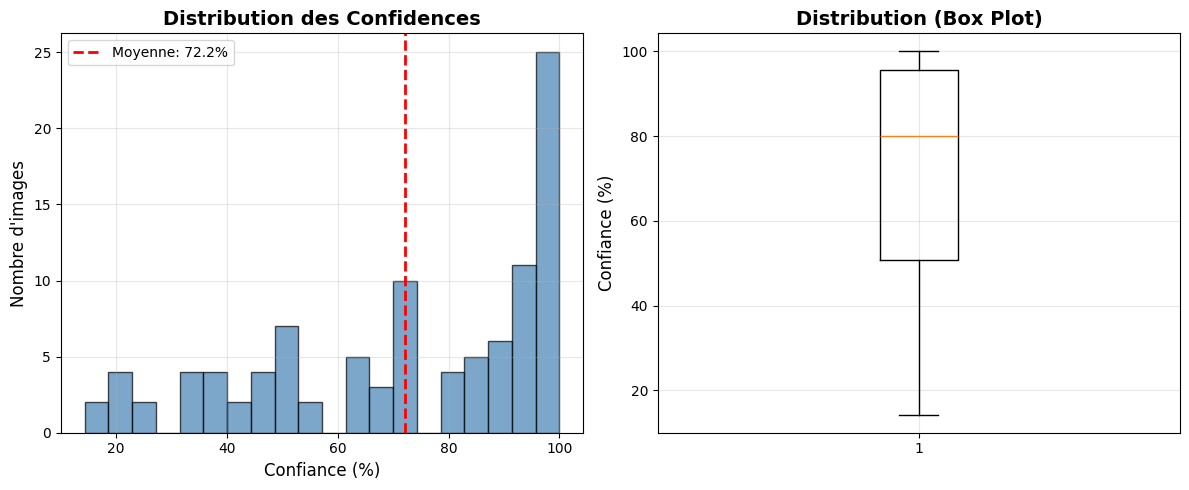


📊 Statistiques Confiance:
   Moyenne: 72.19%
   Médiane: 80.01%
   Min: 14.29%
   Max: 100.00%
   Images >50% confiance: 77/100 (77.0%)
   Images >80% confiance: 50/100 (50.0%)


In [25]:
# Tester sur plus d'images pour stats
n_test = 100
test_images_sample = list(test_dir.glob('*.jpg'))[:n_test]

confidences = []
print(f'🔍 Test sur {len(test_images_sample)} images...')

for img_path in test_images_sample:
    try:
        top_classes, top_probs, _ = predict_vehicle(
            img_path, model, class_names, device, top_k=1
        )
        confidences.append(top_probs[0])
    except:
        continue

# Stats
confidences = np.array(confidences)

plt.figure(figsize=(12, 5))

# Histogramme
plt.subplot(1, 2, 1)
plt.hist(confidences * 100, bins=20, color='steelblue', edgecolor='black', alpha=0.7)
plt.axvline(confidences.mean() * 100, color='red', linestyle='--', 
            linewidth=2, label=f'Moyenne: {confidences.mean():.1%}')
plt.xlabel('Confiance (%)', fontsize=12)
plt.ylabel('Nombre d\'images', fontsize=12)
plt.title('Distribution des Confidences', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

# Box plot
plt.subplot(1, 2, 2)
plt.boxplot(confidences * 100, vert=True)
plt.ylabel('Confiance (%)', fontsize=12)
plt.title('Distribution (Box Plot)', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\n📊 Statistiques Confiance:')
print(f'   Moyenne: {confidences.mean():.2%}')
print(f'   Médiane: {np.median(confidences):.2%}')
print(f'   Min: {confidences.min():.2%}')
print(f'   Max: {confidences.max():.2%}')
print(f'   Images >50% confiance: {(confidences > 0.5).sum()}/{len(confidences)} ({(confidences > 0.5).mean():.1%})')
print(f'   Images >80% confiance: {(confidences > 0.8).sum()}/{len(confidences)} ({(confidences > 0.8).mean():.1%})')

## 🎬 Test sur VOTRE Image

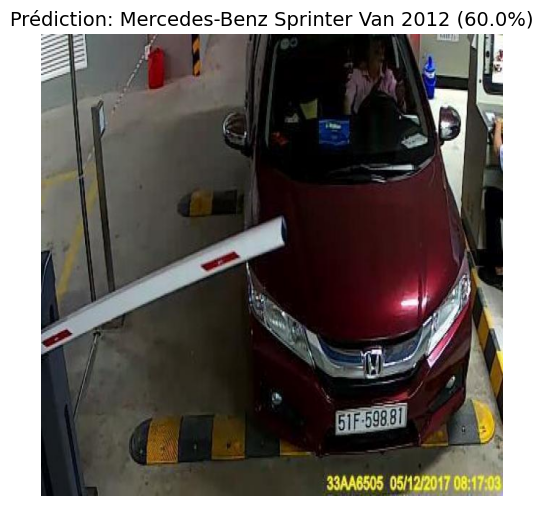

In [29]:
# ⚠️ REMPLACEZ par le chemin vers votre image
YOUR_IMAGE = '/mnt/c/DEV/JEDHA/FULLSTACK_WSL/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/YOLO8-n/ROBOFLOW_universe/sample/CarLongPlate141_jpg.rf.3fa51db04ba8cea9f5321f82b97d218f.jpg'

# Décommentez pour tester:
top_classes, top_probs, image = predict_vehicle(YOUR_IMAGE, model, class_names, device)
plt.figure(figsize=(10, 6))
plt.imshow(image)
plt.title(f'Prédiction: {top_classes[0]} ({top_probs[0]:.1%})', fontsize=14)
plt.axis('off')
plt.show()

## ✅ Résumé

Votre modèle est **opérationnel** et prêt pour :
1. Intégration avec système ALPR
2. Déploiement en production
3. Tests terrain

**Performances** : ~74% accuracy (13 epochs)

---